In [1]:
# Matches UAV Trajectories, Image Timing Files, and Weather Station Data
# PBB 4/14/25
# Includes ERA-5 Data
import sys
sys.path.append('../')
from helper.lablidar.Classes import Project
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
from datetime import datetime, timedelta, timezone
from gps_time import GPSTime
import seaborn as sns
from dotenv import load_dotenv
import os

# load relevant file paths from .env file
load_dotenv()

# set all your file paths
DATADIR = os.getenv("DATADIR")
FIGDIR = os.getenv("FIGDIR")
STATSDIR = os.getenv("STATSDIR")
OUTDIR = os.getenv("OUTDIR")
TRAJDIR = os.getenv("TRAJDIR")

imagetimingdir= Path(f'{DATADIR}/in/ImageTimingFiles/')
weatherf = Path(f'{DATADIR}/in/WeatherData_ThermalLandscapes_curated_v2.csv')
era5_f = Path(f'{DATADIR}/in/ERA5_exclosurevalues_curated.csv')

# Define project paths
projdirs = [Path(os.getenv('NKUHLU')),
            Path(os.getenv('ROANCAMP')),
            Path((os.getenv('LETABA'))),
            Path(os.getenv('MAKHOHLOLA')),
            Path(os.getenv('BUFFALOCAMP')),
            Path(os.getenv('HLANGWINE'))]

# paths to the image timing (.txt) files you want to use 
# needs to match the order of the projects above
imgtimefiles = [Path(f'{DATADIR}/in/ImageTimingFiles/Nkuhlu/cam1_multiband_allflights_NewImgTiming.txt'),
                Path(f'{DATADIR}/in/ImageTimingFiles/RoanCamp/RoanCamp_thermal_image_timing.txt'),
                Path(f'{DATADIR}/in/ImageTimingFiles/Letaba/Letaba_thermal_image_timing.txt'),
                Path(f'{DATADIR}/in/ImageTimingFiles/Makhohlola/thermal_imagetiming.txt'),
                Path(f'{DATADIR}/in/ImageTimingFiles/BuffaloCamp/thermaltiming.txt'),
                Path(f'{DATADIR}/in/ImageTimingFiles/Hlangwine/cam1_multiband_NewImgTiming.txt')]
            
# list of sites in same order as above (AS they are spelled in the weather data file)
sites = ['Nkuhlu', 'Roan Camp','Letaba', 'Makhohlola','Buffalo Camp', 'Hlangwine']

# Set the seaborn plot theme to default
# incorporates grey grid into background of figures
custom_params = {"axes.spines.right": False, "axes.spines.top": False}
sns.set_theme(font_scale=1.1, style="ticks", rc=custom_params)

In [2]:
# Read in and Process Weather Data File (for all sites)

# Weather data file (all sites)
weatherdf = pd.read_csv(weatherf.absolute())

weatherdf.dropna(inplace=True)

# Convert weatherdf times to gps times 
# So that you can interpolate temp/RH values
# apply to dataframe
weatherdf['DateTime'] = weatherdf.apply(lambda x: datetime.strptime(f'{x.Date} {x.Time}',
                                                                    '%m/%d/%Y %H:%M'),
                                                                    axis=1)

# Using GPSTime module here to convert from local time to GPS Time of week
weatherdf['GPSTime'] = weatherdf.DateTime.apply(lambda x: GPSTime.from_datetime(x).time_of_week)

# Rewrite the time column to be consistent with the imagetime_df Times, 
# so that they plot on top of each other in matplotlib
weatherdf['Time'] = weatherdf.DateTime.apply(lambda x: x.strftime("%H:%M:%S"))

# Save it!
weatherdf.to_csv(f'{DATADIR}/WeatherDataFrame_DateTime.csv')
weatherdf.Site.unique()

array(['Nkuhlu', 'Buffalo Camp', 'Hlangwine', 'Makhohlola', 'Roan Camp',
       'Letaba'], dtype=object)

/tmp/ipykernel_1339084/2488361585.py:15: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax1.set_xticklabels(ax1.get_xticklabels(), rotation=90)


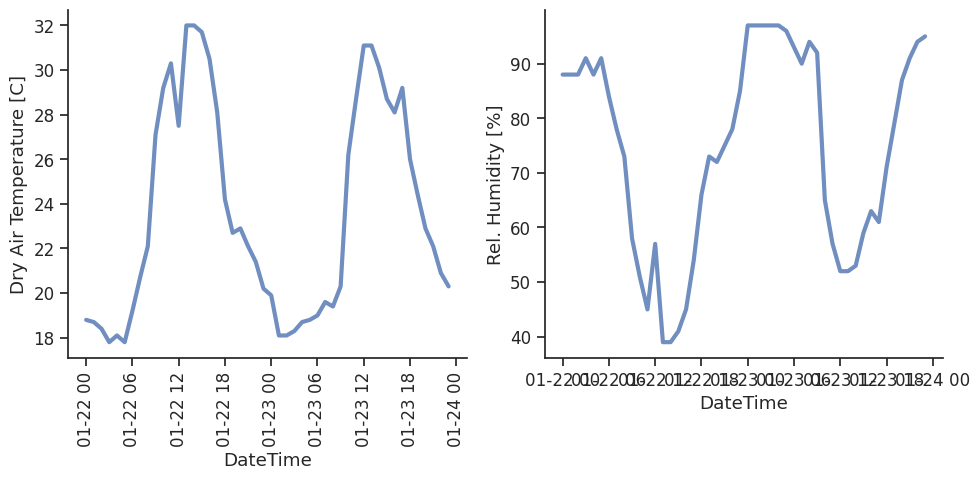

In [3]:
# weatherdf.loc[weatherdf['Site'] == 'Hlangwine'].DateTime.describe()

weatherdf_site = weatherdf.loc[weatherdf['Site'] == 'Hlangwine']

# Plot image captures and weather data
fig2, (ax1, ax2) = plt.subplots(1,2, figsize = (10, 5))

# Air Temp
sns.lineplot(data=weatherdf_site,
                x='DateTime', y='Tdry_C',
                lw=3, alpha=0.8, ax=ax1)

ax1.set_ylabel('Dry Air Temperature [C]')
fig2.tight_layout()
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=90)

# Rel Humidity
sns.lineplot(data=weatherdf_site,
                x='DateTime', y='Rhum_Perc',
                lw=3, alpha=0.8, ax=ax2)

ax2.set_ylabel('Rel. Humidity [%]')
fig2.tight_layout()


In [4]:
# ERA-5 surface radiation file
era5_df = pd.read_csv(era5_f)

# Miriam's notes on Units
# I think we'll eventually want the times that are closest to the drone flights. 
# I don't know much about ERA5 downwelling LW per se, but what you really want is a
# measurement that is as close as possible to what an upward-pointing LW radiometer would measure.
# Given the description (below), that would be "surface thermal radiation downwards." 
# (Note: "Clear-sky quantities are computed for exactly the same atmospheric conditions of temperature,
# humidity, ozone, trace gases and aerosol, but assuming that the clouds are not there." --
# but you're looking for the most realistic thing [quote from 'further documentation' link, below]).

# ====
# surface thermal radiation downwards:
# "This parameter is the amount of thermal (also known as longwave or terrestrial) radiation
# emitted by the atmosphere and clouds that reaches a horizontal plane at the surface of the Earth.

# The surface of the Earth emits thermal radiation, some of which is absorbed by the atmosphere and clouds. 
# The atmosphere and clouds likewise emit thermal radiation in all directions, 
# some of which reaches the surface (represented by this parameter). See further documentation.

# This parameter is accumulated over a particular time period which depends on the data extracted. 
# The units are joules per square metre (J m-2). To convert to watts per square metre (W m-2),
# the accumulated values should be divided by the accumulation period expressed in seconds. 
# The ECMWF convention for vertical fluxes is positive downwards."

# make a datetime column
era5_df['date_time'] = pd.to_datetime(era5_df['time'], format='%m/%d/%Y %H:%M')

# Using GPSTime module here to convert from local time to GPS Time of week
era5_df['GPSTime'] = era5_df.date_time.apply(lambda x: GPSTime.from_datetime(x).time_of_week)

era5_df.head()

,name,date,time,STRD,STRD_Clearsky,date_time,GPSTime
0,BuffaloCamp100m,21012020,1/21/2020 5:00,1330614.364,1211792.374,2020-01-21 05:00:00,190800.0
1,BuffaloCamp100m,21012020,1/21/2020 6:00,1261379.836,1226946.681,2020-01-21 06:00:00,194400.0
2,BuffaloCamp100m,21012020,1/21/2020 7:00,1313147.409,1248368.441,2020-01-21 07:00:00,198000.0
3,BuffaloCamp100m,21012020,1/21/2020 8:00,1327068.222,1267256.161,2020-01-21 08:00:00,201600.0
4,BuffaloCamp100m,21012020,1/21/2020 9:00,1439348.039,1281263.463,2020-01-21 09:00:00,205200.0


In [5]:
# Functions
def convertGPSTimetoLocalTime(time, day, month, year, offset=2):
    # offset is offset from GTCT time (SA is +2)
    # force to int for use in datetime 
    day = int(day)
    month = int(month)
    year = int(year)

    # Make datetime object of input GPStime
    dt = datetime(day=day, month=month, year=year, tzinfo=timezone.utc)

    # Start the time of that week (since GPS TOW counts seconds since the start of the week)
    # Subtract number of days  isoweekday() of base station date to count back to the beg. of week
    start_of_week = datetime(year = year,
                             day = day,
                             month = month) - timedelta(days=dt.isoweekday())

    # Use datetime's timedelta to add the GPS TOW seconds to the start of the week datetime
    curr_dt = start_of_week + timedelta(seconds=time)
    
    # Convert to local time using offset from gtc
    curr_dt = curr_dt + timedelta(hours=offset)

    # Set the current date and time! Easy.
    date = curr_dt.strftime("%Y-%m-%d")
    UTC = curr_dt.strftime("%H:%M:%S")
                             
    return curr_dt



def hlangwine_date_checker(fname:str):
    '''
    Manual date correction for hlangwine- which was split over 2 days
    '''
    # if (('Flight1' in fname) | ('Flight2' in fname)):
    #     day = 22
    # else:
    #     day = 23
    
    if 'Flight1' in fname:
        day = 23
    else:
        day = 22
        
    return day

In [6]:
# projdates = ['2020-01-16', '2020-12-04', '2020-12-07', '2020-01-24', '2020-01-21', '2020-01-22'] 
# projstrs = ['NkuluEP', 'RoanCamp', 'LetabaExclosure', 'MakhohlolaEP', 'BuffaloCamp100m', 'HlangwineEP']
# projepsgs = ['32631', '32736', '32736', '32631', '32736', '32736']

# for projdate, projstr, projepsg, itf, site in zip(projdates, projstrs, projepsgs, imgtimefiles, sites):
    
#     UTMTraj = pd.read_csv(f'{TRAJDIR}/{projdate}_{projstr}_Trajectory_EPSG{projepsg}.csv')
    
#     # Read in image timing file
#     it = pd.read_csv(itf, sep=' ', header=None,
#                      names=['GPSTime', 'Imagef'])
  
#     it['date_time'] = it.GPSTime.apply(lambda x: convertGPSTimetoLocalTime(x))
    
#     print(it.head())

/tmp/ipykernel_1339084/71854943.py:197: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax1.set_xticklabels(ax1.get_xticklabels(), rotation=90)
/tmp/ipykernel_1339084/71854943.py:207: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax2.set_xticklabels(ax2.get_xticklabels(), rotation=90)
/tmp/ipykernel_1339084/71854943.py:197: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax1.set_xticklabels(ax1.get_xticklabels(), rotation=90)
/tmp/ipykernel_1339084/71854943.py:207: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax2.set_xticklabels(ax2.get_xticklabels(), rotation=90)
/tmp/ipykernel_1339084/71854943.py:197: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax1.set_xticklabels(ax1.get_xticklabels(), rotation=90)
/tmp/ipykernel_1339084/71854943.py:207: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax2.set_xticklabel

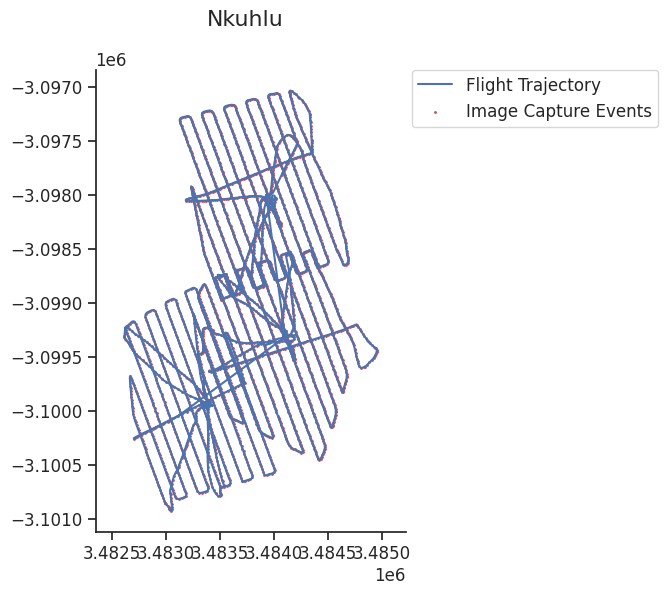

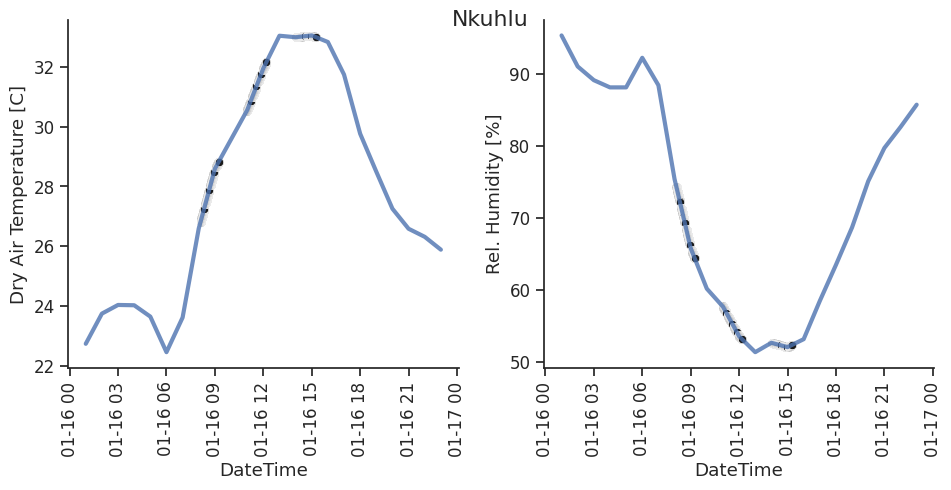

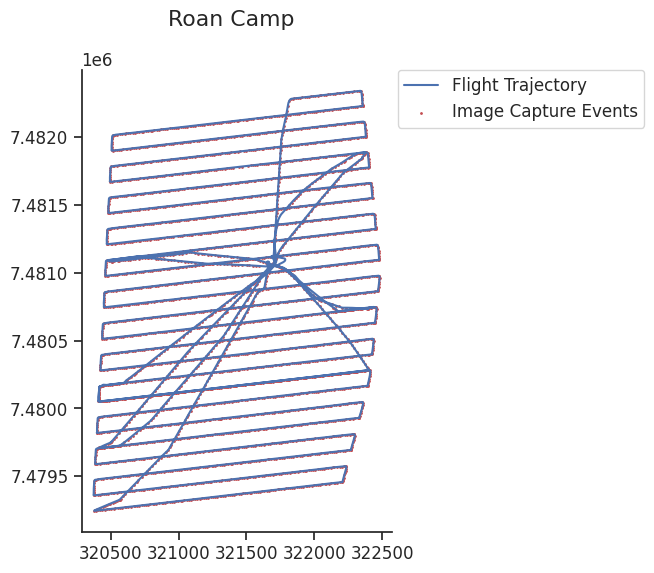

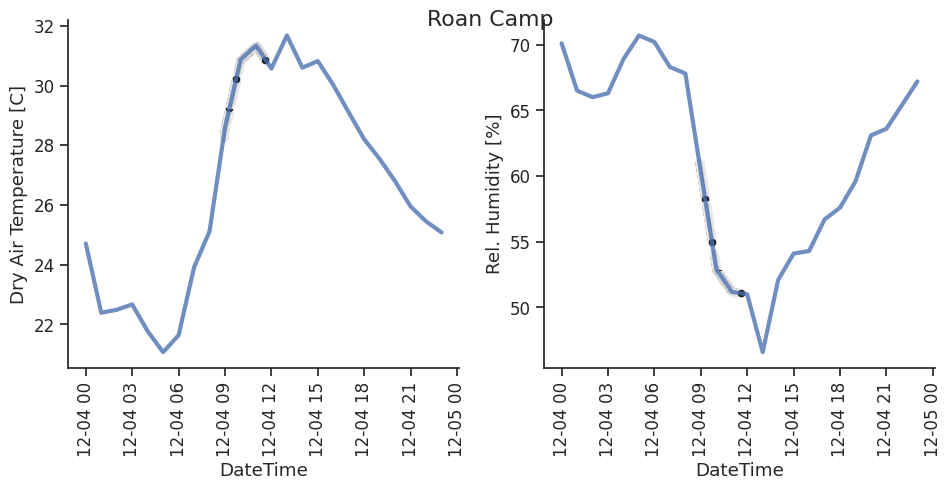

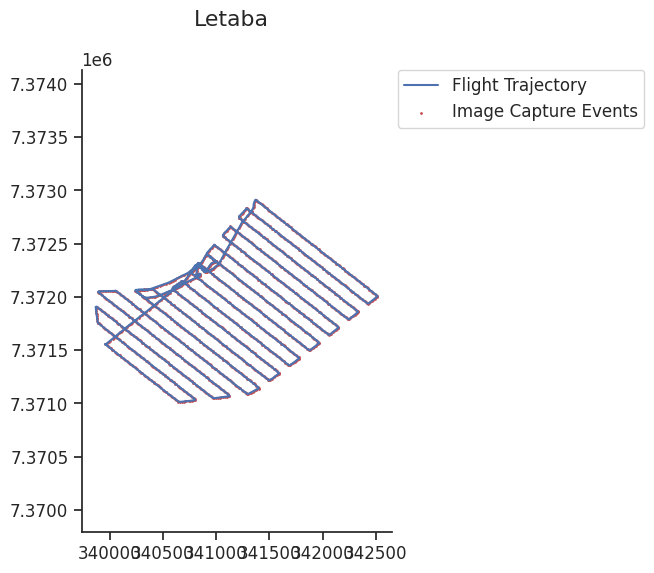

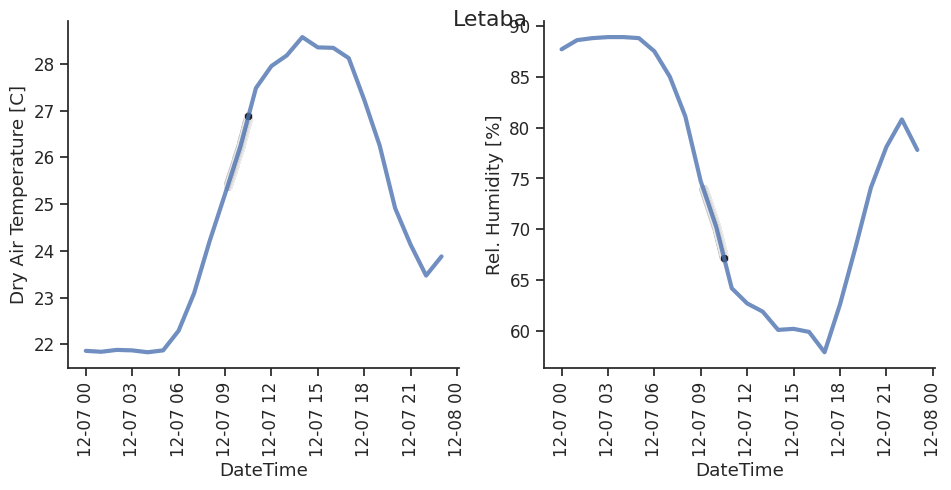

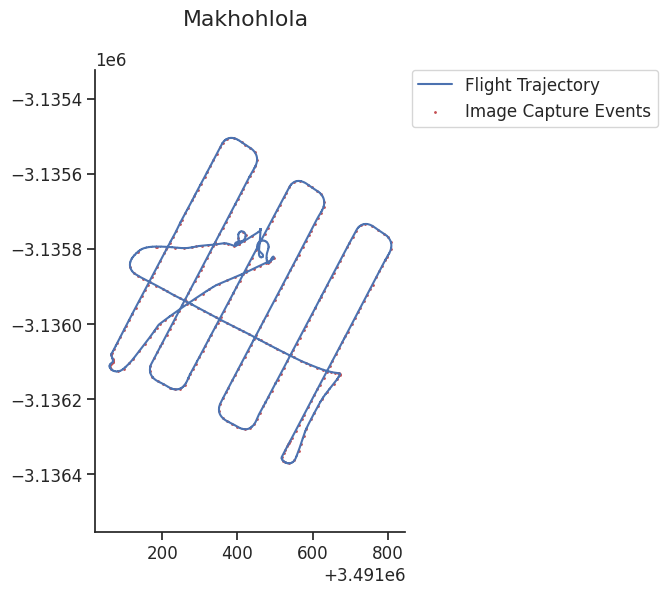

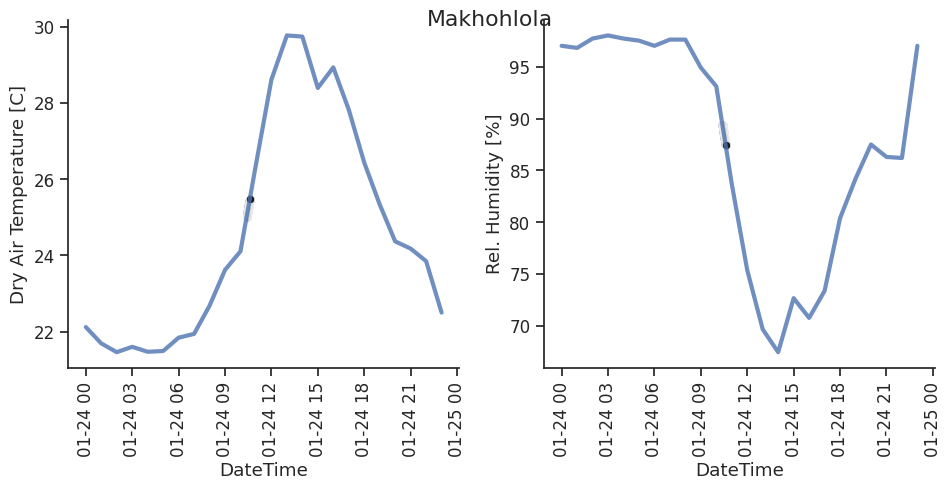

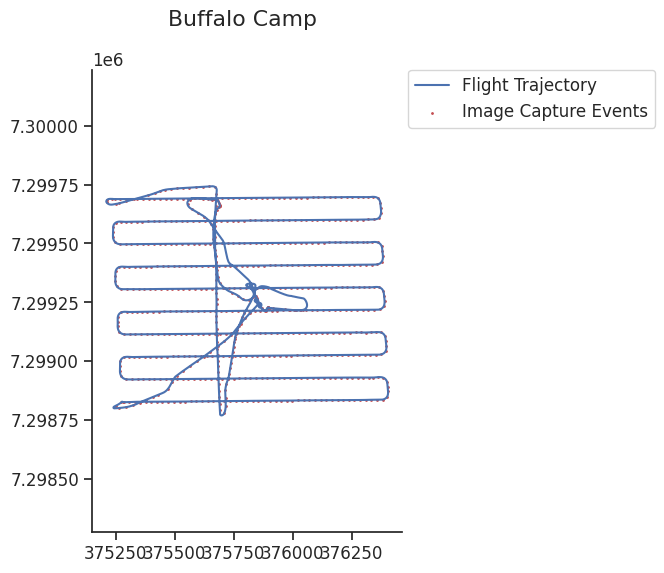

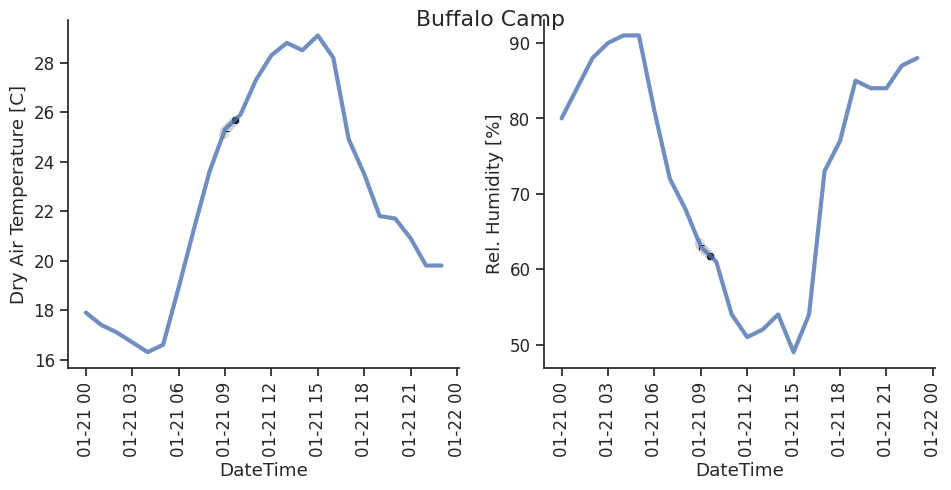

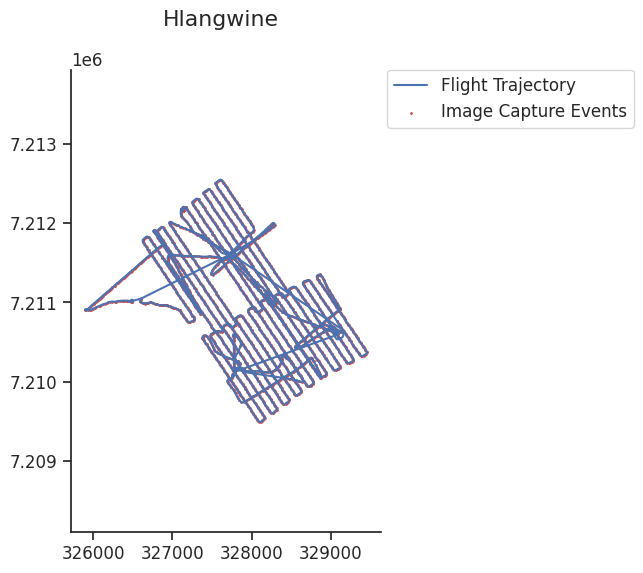

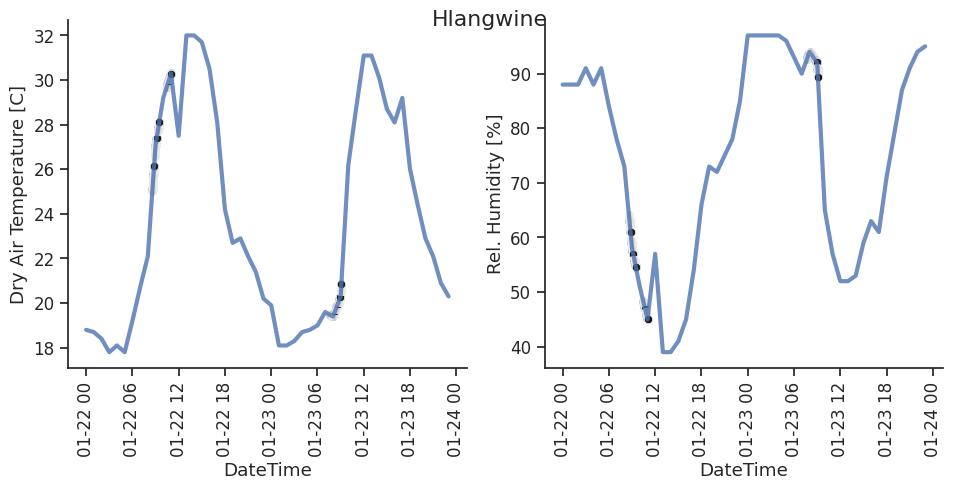

In [7]:
projdates = ['2020-01-16', '2020-12-04', '2020-12-07', '2020-01-24', '2020-01-21', '2020-01-22'] 
projstrs = ['NkuluEP', 'RoanCamp', 'LetabaExclosure', 'MakhohlolaEP', 'BuffaloCamp100m', 'HlangwineEP']
projepsgs = ['32631', '32736', '32736', '32631', '32736', '32736']

for projdate, projstr, projepsg, itf, site in zip(projdates, projstrs, projepsgs, imgtimefiles, sites):
    
    UTMTraj = pd.read_csv(f'{TRAJDIR}/{projdate}_{projstr}_Trajectory_EPSG{projepsg}.csv')
    
    # Read in image timing file
    it = pd.read_csv(itf, sep=' ', header=None,
                     names=['GPSTime', 'Imagef'])
    
    # get position (easting, northing, alt.) of each image, by linear interpolation
    North_interp = []
    East_interp = [] 
    Alt_interp = []
    
    # Comparing trajectory times and image times (which should both be in relation to UTC)
    for t in it.GPSTime:

        # Index of time in trajectory closest to the image capture
        idx = np.argmin(np.abs(UTMTraj.GPSTime - t))

        # Get the interpolated position
        # Using the index 
        North_interp.append(np.interp(t,
                                     UTMTraj.GPSTime[(idx-1):idx:(idx+1)],
                                     UTMTraj.Northing[(idx-1):idx:(idx+1)]))

        East_interp.append(np.interp(t,
                                 UTMTraj.GPSTime[(idx-1):idx:(idx+1)],
                                 UTMTraj.Easting[(idx-1):idx:(idx+1)])) 

        Alt_interp.append(np.interp(t,
                             UTMTraj.GPSTime[(idx-1):idx:(idx+1)],
                             UTMTraj.Altitude[(idx-1):idx:(idx+1)]))
    
    # Make a plot of the trajectory for reference
    fig1, ax1 = plt.subplots(figsize=(4, 6))
    ax1.plot(UTMTraj.Easting, UTMTraj.Northing, label='Flight Trajectory')
    ax1.scatter(East_interp, North_interp, c='r', s=1, label='Image Capture Events')
    plt.axis('equal')
    ax1.legend()
    plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0)
    
    fig1.suptitle(site)
    
    fig1.savefig(f'{FIGDIR}/Trajectories/{projdate}_{projstr}_Trajectory.png', dpi=300)
    
    # Make an image trajectory df
    imgtime_df = it.assign(Northing=North_interp, 
                           Easting=East_interp,
                           Altitude=Alt_interp,
                           Site=projstr,
                           Date=projdate)
    
    # Compute local time of each image
    if site == 'Hlangwine':
        # print(imgtime_df.head())
        
        # hlangwine split over 2 days, and need to correct the "day" attribute
        # 2020-01-22 & 2020-01-23
        imgtime_df['day'] = imgtime_df.Imagef.apply(hlangwine_date_checker)
        
        # NOTE: things get really weird when you use both day 23 (flight1) and 22 (all other flights)
        # Maybe just leave out flight 1 
        # and move on with life 5/9/25
        # try dropping all flight1 dates
        imgtime_df = imgtime_df.loc[imgtime_df.day == 22, :]
        
        # print(imgtime_df.Imagef.head())
        # print(imgtime_df.day.head())
        # print(imgtime_df.Imagef.tail())
        # print(imgtime_df.day.tail())
        
        m = projdate.split('-')[1]
        y = projdate.split('-')[0]
        
        imgtime_df['DateTime'] = imgtime_df.apply(lambda row: convertGPSTimetoLocalTime(row['GPSTime'], day=row['day'], month=m, year=y, offset=2), axis=1)
        imgtime_df['Time'] = imgtime_df.DateTime.apply(lambda x: x.strftime("%H:%M:%S"))
        
        # print(imgtime_df.DateTime.tail())
        # print(imgtime_df.Time.tail())
        
    else:
            
        d = int(projdate.split('-')[2])
        m = int(projdate.split('-')[1])
        y = int(projdate.split('-')[0])
        
        imgtime_df['DateTime'] = imgtime_df.GPSTime.apply(lambda t: convertGPSTimetoLocalTime(t, day=d, month=m, year=y, offset=2))
        imgtime_df['Time'] = imgtime_df.GPSTime.apply(lambda t: convertGPSTimetoLocalTime(t, day=d, month=m, year=y, offset=2).strftime("%H:%M:%S"))
    
    # # # Connect Images to Weather Data and Trajectory
    # Subset to current project site
    # note: site names might be slightly different/mispelled... Fix that someday
    weatherdf_site = weatherdf.loc[weatherdf.Site == site]
    
    # Add in weather information by interpolation
    RH_interp = []
    Temp_interp = []
    Dewpoint_C_interp = []
    Leaf_Wet_Perc_interp = []
    Srad_mJ_interp = []
    Eto_mm_interp = []
    Absolute_RH_gm3_interp = []
    Specific_RH_gkg_interp = []
    
    # comparing weather times (local time) and image times (UTC)
    # so have to use GPSTime to convert times back to gps time of week
    for dt in imgtime_df.DateTime:
        
        t = GPSTime.from_datetime(dt).time_of_week

        # Index of time in trajectory closest to the image capture
        idx = np.argmin(np.abs(weatherdf_site.GPSTime - t))

        # Get the interpolated weather values
        RH_interp.append(np.interp(t,
                                   weatherdf_site.GPSTime[(idx-3):(idx+3)],
                                   weatherdf_site.Rhum_Perc[(idx-3):(idx+3)]))

        Temp_interp.append(np.interp(t,
                                     weatherdf_site.GPSTime[(idx-3):(idx+3)],
                                     weatherdf_site.Tdry_C[(idx-3):(idx+3)])) 
        
        Dewpoint_C_interp.append(np.interp(t,
                                     weatherdf_site.GPSTime[(idx-3):(idx+3)],
                                     weatherdf_site.Dewpoint_C[(idx-3):(idx+3)]))
        
        Leaf_Wet_Perc_interp.append(np.interp(t,
                                     weatherdf_site.GPSTime[(idx-3):(idx+3)],
                                     weatherdf_site.Leaf_Wet_Perc[(idx-3):(idx+3)]))
        
        Srad_mJ_interp.append(np.interp(t,
                                     weatherdf_site.GPSTime[(idx-3):(idx+3)],
                                     weatherdf_site.Srad_mJ[(idx-3):(idx+3)]))
        
        Eto_mm_interp.append(np.interp(t,
                                     weatherdf_site.GPSTime[(idx-3):(idx+3)],
                                     weatherdf_site.Eto_mm[(idx-3):(idx+3)]))
        
        Absolute_RH_gm3_interp.append(np.interp(t,
                                     weatherdf_site.GPSTime[(idx-3):(idx+3)],
                                     weatherdf_site.Absolute_RH_gm3[(idx-3):(idx+3)]))
        
        Specific_RH_gkg_interp.append(np.interp(t,
                                     weatherdf_site.GPSTime[(idx-3):(idx+3)],
                                     weatherdf_site.Specific_RH_gkg[(idx-3):(idx+3)]))
    
    # Add weather data
    imgtime_df['RH'] = RH_interp
    imgtime_df['AirTemp'] = Temp_interp
    imgtime_df['Dewpoint_C'] = Dewpoint_C_interp
    imgtime_df['Leaf_Wet_Perc'] = Leaf_Wet_Perc_interp
    imgtime_df['Srad_mJ'] = Srad_mJ_interp
    imgtime_df['Eto_mm'] = Eto_mm_interp
    imgtime_df['Absolute_RH_gm3'] = Absolute_RH_gm3_interp
    imgtime_df['Specific_RH_gkg'] = Specific_RH_gkg_interp
    
    # # # do the same thing with the ERA 5 data
    era5_df_site = era5_df.loc[era5_df['name'] == projstr]
    STRD_interp = []
    STRD_Clearsky_interp = []
    
    for dt in imgtime_df.DateTime:
        
        t = GPSTime.from_datetime(dt).time_of_week
        
        # Index of time in trajectory closest to the image capture
        idx = np.argmin(np.abs(era5_df_site.GPSTime - t))
        
        STRD_interp.append(np.interp(t,
                                    era5_df_site.GPSTime[(idx-3):(idx+3)],
                                    era5_df_site.STRD[(idx-3):(idx+3)]))
        
        STRD_Clearsky_interp.append(np.interp(t,
                                    era5_df_site.GPSTime[(idx-3):(idx+3)],
                                    era5_df_site.STRD_Clearsky[(idx-3):(idx+3)]))
        
    imgtime_df['STRD'] = STRD_interp
    imgtime_df['STRD_Clearsky'] = STRD_Clearsky_interp
    
    # Save it
    imgtime_df.to_csv(f'{DATADIR}/in/ImageTrajectories/{projstr}_ImageTrajectory_withWeather.csv')

    # Plot image captures and weather data
    fig2, (ax1, ax2) = plt.subplots(1,2, figsize = (10, 5))
    
    # Air Temp
    sns.lineplot(data=weatherdf_site,
                 x='DateTime', y='Tdry_C',
                 lw=3, alpha=0.8, ax=ax1)

    ax1.set_ylabel('Dry Air Temperature [C]')
    fig2.tight_layout()
    ax1.set_xticklabels(ax1.get_xticklabels(), rotation=90)
    sns.scatterplot(data = imgtime_df, x='DateTime', y='AirTemp', color='k', ax=ax1)
    
    # Rel Humidity
    sns.lineplot(data=weatherdf_site,
                 x='DateTime', y='Rhum_Perc',
                 lw=3, alpha=0.8, ax=ax2)

    ax2.set_ylabel('Rel. Humidity [%]')
    fig2.tight_layout()
    ax2.set_xticklabels(ax2.get_xticklabels(), rotation=90)
    sns.scatterplot(data = imgtime_df, x='DateTime', y='RH', color='k', ax=ax2)
    
    fig2.suptitle(site)
    
    fig2.savefig(f'{FIGDIR}/WeatherPlots/{projdate}_{projstr}_WeatherPlotwithImageEvents.png', dpi=300)

In [8]:
imgtime_df.head()

,GPSTime,Imagef,Northing,Easting,Altitude,Site,Date,day,DateTime,Time,RH,AirTemp,Dewpoint_C,Leaf_Wet_Perc,Srad_mJ,Eto_mm,Absolute_RH_gm3,Specific_RH_gkg,STRD,STRD_Clearsky
1296,282910.453,Flight2_cam1-000-000000-0,7.210222e+06,327857.137602,654.919861,HlangwineEP,2020-01-22,22,2020-01-22 08:35:10.453,08:35:10,64.206446,25.031185,17.668998,0.0,1.768990,0.321385,15.088650,14.680723,1.466174e+06,1.282119e+06
1297,282912.054,Flight2_cam1-000-000001-0,7.210233e+06,327855.351043,660.593750,HlangwineEP,2020-01-22,22,2020-01-22 08:35:12.054,08:35:12,64.199775,25.033408,17.669483,0.0,1.769345,0.321470,15.089081,14.681217,1.466192e+06,1.282130e+06
1298,282915.525,Flight2_cam1-000-000002-0,7.210255e+06,327828.925166,669.124390,HlangwineEP,2020-01-22,22,2020-01-22 08:35:15.525,08:35:15,64.185312,25.038229,17.670534,0.0,1.770117,0.321653,15.090016,14.682287,1.466231e+06,1.282154e+06
1299,282915.791,Flight2_cam1-000-000003-0,7.210256e+06,327826.247855,669.241028,HlangwineEP,2020-01-22,22,2020-01-22 08:35:15.791,08:35:15,64.184204,25.038599,17.670614,0.0,1.770176,0.321667,15.090088,14.682369,1.466234e+06,1.282156e+06
1300,282917.793,Flight2_cam1-000-000004-0,7.210266e+06,327802.606071,669.214417,HlangwineEP,2020-01-22,22,2020-01-22 08:35:17.793,08:35:17,64.175862,25.041379,17.671221,0.0,1.770621,0.321772,15.090628,14.682986,1.466257e+06,1.282170e+06


In [9]:
# Last, Combine all the files together for easy loading in R
df_list = []

for p in projstrs:
    
    df = pd.read_csv(f'{DATADIR}/in/ImageTrajectories/{p}_ImageTrajectory_withWeather.csv')
    
    df.drop('Unnamed: 0', axis=1, inplace=True)

    df_list.append(df)

# stick list together
IT_df = pd.concat(df_list)

# save
IT_df.to_csv(f'{DATADIR}/in/ImageTrajectories/AllSites_ImageTrajectory_withWeather.csv', index=False)